## This notebook is strongly based on 03_advanced_image_classification.ipynb

The below cell is based on an answer from: https://stackoverflow.com/questions/49817409/running-a-jupyter-notebook-from-another-notebook

#### Can probably be removed(?): The batch normalization teqnique below is based on inspiration from Deep Learning with Python, Third edition. Chapter: 9, Batch normalization

In [10]:
import keras
import matplotlib.pyplot as plt
import utils

In [11]:

model = keras.models.load_model("../models/augment.keras")
model.summary()

Model: "v4_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_402     │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ best_data_augmenta… │ (None, 300, 300,  │          0 │ input_layer_402[… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_201       │ (None, 300, 300,  │          0 │ best_data_augmen… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1407         │ (None, 298, 298,  │        896 │ rescaling_201[0]… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1408         │ (None, 296, 296,  │      9,248 │ conv2d_1407[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_603   │ (None, 148, 148,  │          0 │ conv2d_1408[0][0] │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1409         │ (None, 146, 146,  │     18,496 │ max_pooling2d_60… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1410         │ (None, 144, 144,  │     36,928 │ conv2d_1409[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_604   │ (None, 72, 72,    │          0 │ conv2d_1410[0][0] │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1411         │ (None, 70, 70,    │     73,856 │ max_pooling2d_60… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1412         │ (None, 68, 68,    │    147,584 │ conv2d_1411[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_605   │ (None, 34, 34,    │          0 │ conv2d_1412[0][0] │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1413         │ (None, 32, 32,    │    295,168 │ max_pooling2d_60… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ conv2d_1413[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_402 (Dense)   │ (None, 256)       │     65,792 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_403 (Dense)   │ (None, 128)       │     32,896 │ dense_402[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lvl1 (Dense)        │ (None, 1)         │        129 │ dense_403[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lvl2 (Dense)        │ (None, 7)         │        903 │ dense_403[0][0] 

 Total params: 681,896 (2.60 MB)

 Trainable params: 681,896 (2.60 MB)

 Non-trainable params: 0 (0.00 B)

#### The cell below is from Deep Learning with Python, Third edition. Chapter: 8, Fitting the model

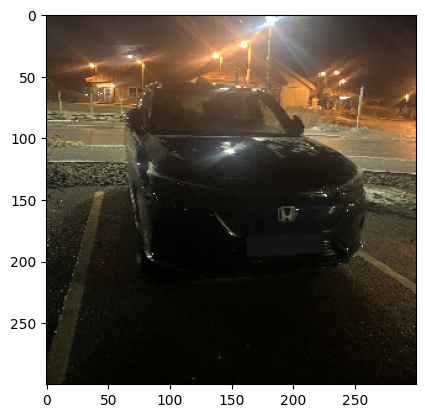

In [12]:
img = keras.utils.load_img("../datasett_src/Egenprodusert/non-tesla/dark/IMG_1895.jpeg", target_size=(300,300,3))
plt.imshow(img)

img_array = keras.utils.img_to_array(img)
img_array = keras.ops.expand_dims(img_array, 0)  # Create batch axis

### The below cells are strongly based on Deep Learning with Python, Third edition. Chapter: 10, Visualizing heatmaps of class activation

In [13]:
import keras
import tensorflow as tf
import numpy as np

# -------------------------------------------------
# 1. Last conv layer model: image -> conv2d_1413
# -------------------------------------------------
last_conv_layer = model.get_layer("conv2d_1413")

last_conv_layer_model = keras.Model(
    inputs=model.input,
    outputs=last_conv_layer.output,
    name="last_conv_layer_model",
)

# -------------------------------------------------
# 2. Classifier model: conv2d_1413 output -> head
#    (example: lvl2, 7-class head)
# -------------------------------------------------
gap_layer   = model.get_layer("global_average_pooling2d_201")
dense_402   = model.get_layer("dense_402")
dense_403   = model.get_layer("dense_403")
lvl2_layer  = model.get_layer("lvl2")  # use lvl1_layer = model.get_layer("lvl1") for lvl1

# Shape of last conv output, e.g. (None, 32, 32, 256)
conv_output_shape = last_conv_layer.output.shape[1:]
# For your conv2d_1413 this should be (32, 32, 256)


# THIS is the proper classifier input: a KerasTensor
classifier_input = keras.Input(shape=conv_output_shape, name="conv_input")

x = classifier_input          # start from the conv feature map
x = gap_layer(x)              # reuse existing layers
x = dense_402(x)
x = dense_403(x)
classifier_output = lvl2_layer(x)

classifier_model = keras.Model(
    inputs=classifier_input,
    outputs=classifier_output,
    name="lvl2_classifier_from_conv",
)

# -------------------------------------------------
# 3. Grad-CAM helpers
# -------------------------------------------------
def get_top_class_gradients(img_array):
    # img_array: shape (1, 300, 300, 3)
    last_conv_layer_output = last_conv_layer_model(img_array)

    with tf.GradientTape() as tape:
        tape.watch(last_conv_layer_output)
        preds = classifier_model(last_conv_layer_output)

        # Multi-class: index of top predicted class
        top_pred_index = tf.argmax(preds[0])
        top_class_channel = preds[:, top_pred_index]

    grads = tape.gradient(top_class_channel, last_conv_layer_output)
    return grads, last_conv_layer_output


def get_heatmap(img_array):
    grads, last_conv_layer_output = get_top_class_gradients(img_array)
    grads = keras.ops.convert_to_numpy(grads)
    last_conv_layer_output = keras.ops.convert_to_numpy(last_conv_layer_output)

    pooled_grads = np.mean(grads, axis=(0, 1, 2))
    feature_map = last_conv_layer_output[0].copy()  # (H, W, C)

    for i in range(pooled_grads.shape[-1]):
        feature_map[:, :, i] *= pooled_grads[i]

    heatmap = np.mean(feature_map, axis=-1)
    heatmap = np.maximum(heatmap, 0)
    if np.max(heatmap) > 0:
        heatmap /= np.max(heatmap)

    return heatmap * 255


/tmp/ipykernel_127950/3293381117.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


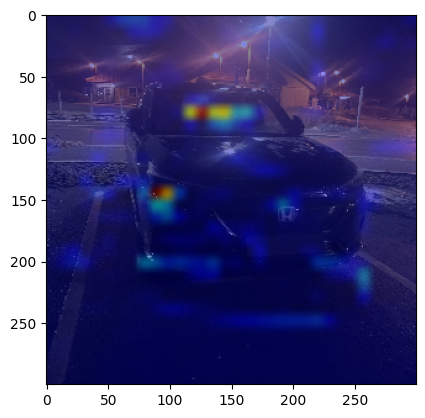

In [14]:
import matplotlib.cm as cm
heatmap = get_heatmap(img_array)

# Uses the "jet" colormap to recolorize the heatmap
jet = cm.get_cmap("jet")
jet_colors = jet(np.arange(256))[:, :3]

# Convertion to int is from: https://www.w3schools.com/python/numpy/numpy_data_types.asp (Converting Data Type on Existing Arrays)
jet_heatmap = jet_colors[(np.round(heatmap)).astype('i')]

# Creates an image that contains the recolorized heatmap
jet_heatmap = keras.utils.array_to_img(jet_heatmap)
jet_heatmap = jet_heatmap.resize((img_array[0].shape[1], img_array[0].shape[0]))
jet_heatmap = keras.utils.img_to_array(jet_heatmap)

# Superimposes the heatmap and the original image
superimposed_img = jet_heatmap + img_array[0]
superimposed_img = keras.utils.array_to_img(superimposed_img)

# Shows the superimposed image
plt.imshow(superimposed_img)

#### Cell below is also based on 03_advanced_image_classification.ipynb

In [6]:
(train_x, train_y), (val_x, val_y), (test_x, test_y) = utils.read_andre_data()

Correction complete!
 - Files found as-is: 2335
 - Extensions corrected: 1431
 - Still missing (not found): 0
Correction complete!
 - Files found as-is: 497
 - Extensions corrected: 310
 - Still missing (not found): 0
Correction complete!
 - Files found as-is: 476
 - Extensions corrected: 331
 - Still missing (not found): 0


In [15]:
base = 0

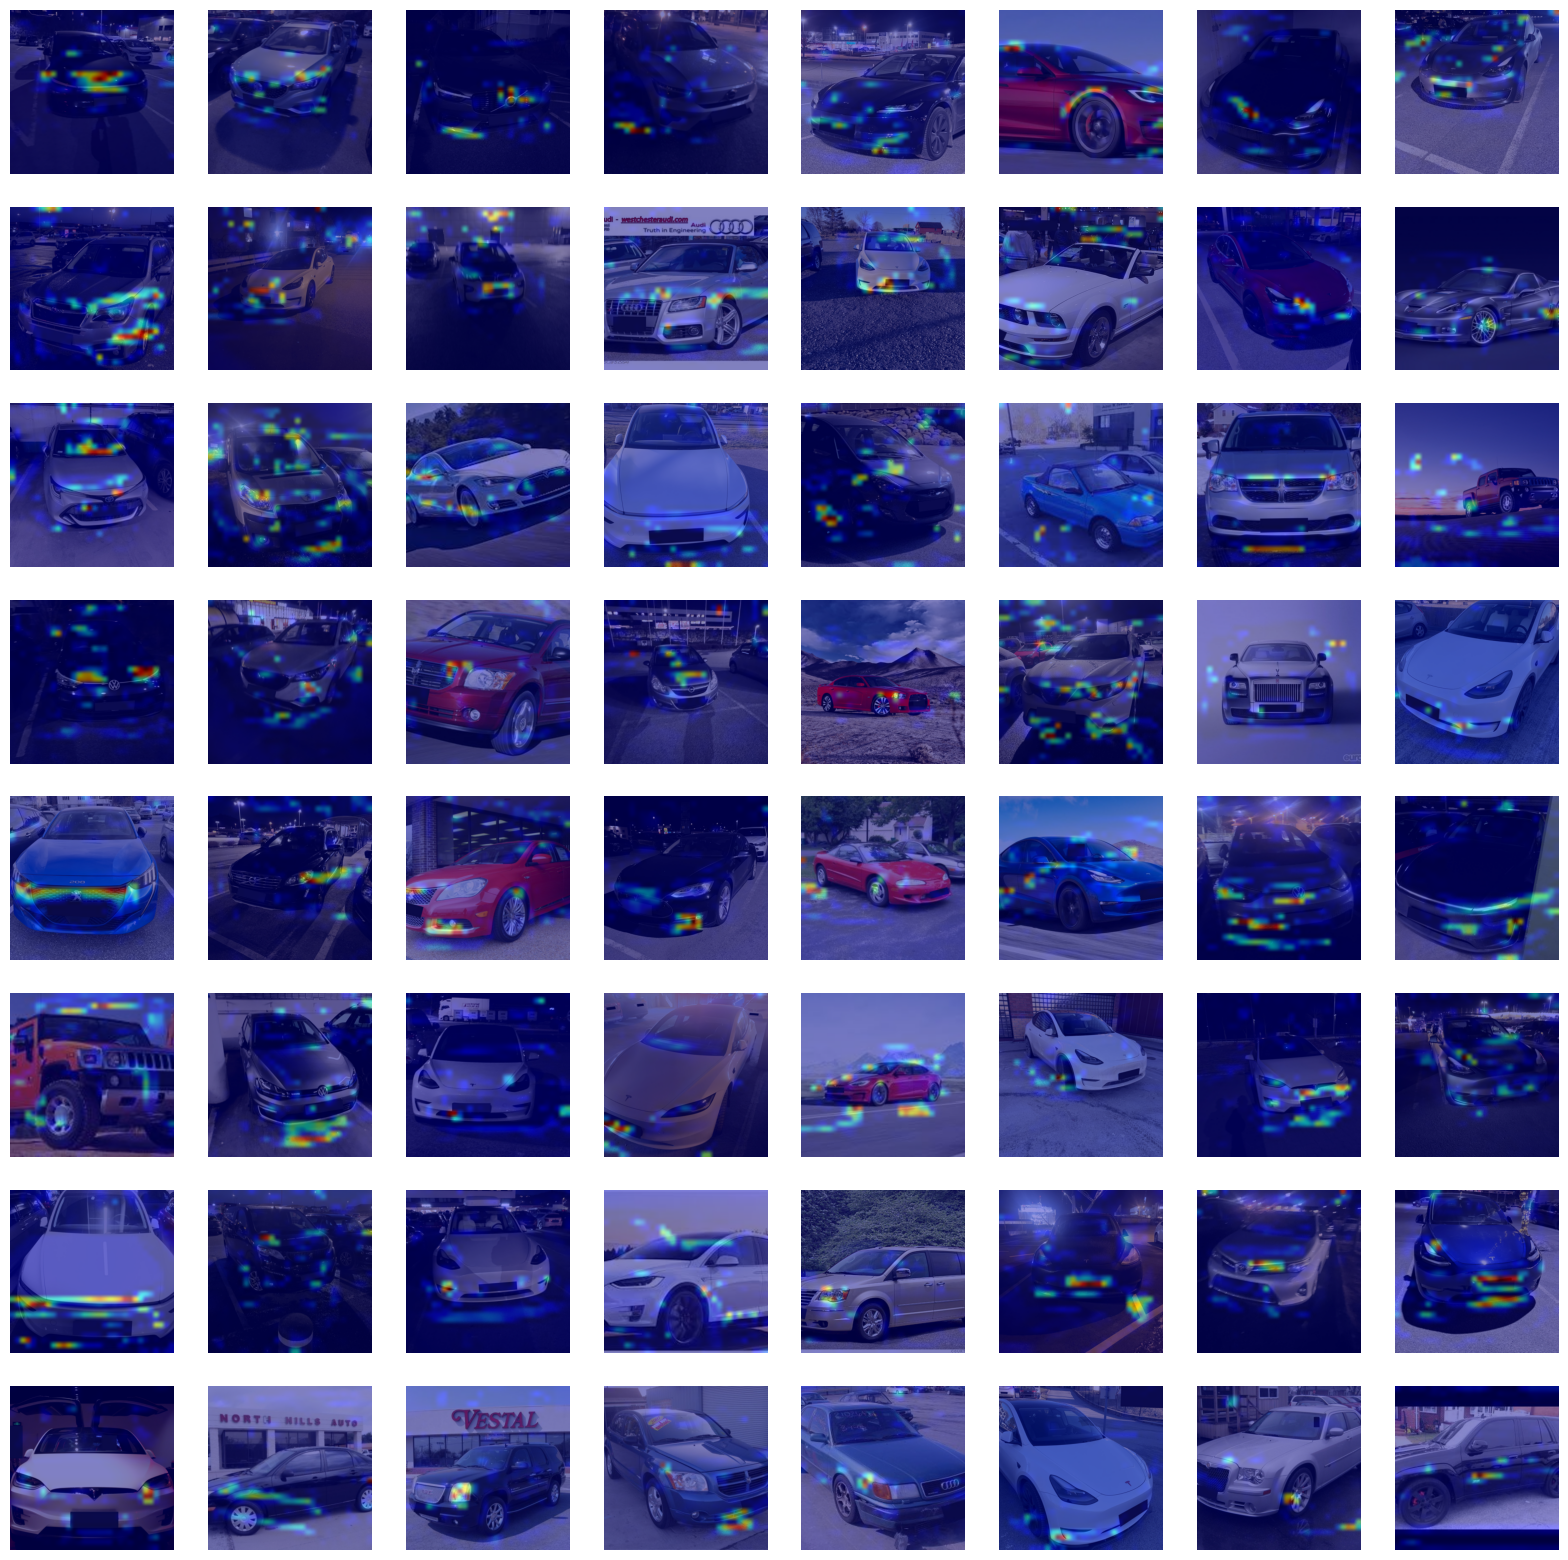

In [18]:
plt.figure(figsize=(20, 20))

num_images = 64  # or min(64, len(val_x))
for i in range(num_images):
    img = val_x[base + i]  # shape (300, 300, 3)

    # If your model still has Rescaling inside, feed raw [0,255] images.
    # If you stripped Rescaling, be sure img is already /255.

    img_batch = np.expand_dims(img, 0)  # shape (1, 300, 300, 3)
    current_heatmap = get_heatmap(img_batch)

    indices = np.clip(np.round(current_heatmap), 0, 255).astype("i")
    current_jet_heatmap = jet_colors[indices]

    current_jet_heatmap = keras.utils.array_to_img(current_jet_heatmap)
    current_jet_heatmap = current_jet_heatmap.resize((img.shape[1], img.shape[0]))
    current_jet_heatmap = keras.utils.img_to_array(current_jet_heatmap)

    superimposed_img = current_jet_heatmap + img
    superimposed_img = keras.utils.array_to_img(superimposed_img)

    ax = plt.subplot(8, 8, i + 1)
    plt.imshow(np.array(superimposed_img).astype("uint8"))
    plt.axis("off")
base += num_images

### The above cells are strongly based on Deep Learning with Python, Third edition. Chapter: 10, Visualizing heatmaps of class activation